In [1]:
import sys, os
from pathlib import Path
work_dir = os.getcwd()
proj_dir = str(Path(work_dir).resolve().parents[0])
sys.path.append(proj_dir)
import time
import sympy as sp
import torch

from bc_learn.Config import Config
from bc_learn.Draw import Draw
from bc_learn.Finetuning import Finetuner
from bc_learn.Generate_data import Data
# from bc_learn.Net_pre import Net, Learner
from bc_learn.Net import Learner
from verify.kvh_verify import KVH


def print_success():
    heart = """
          *****         *****
       ***********   *************
     *************** ***************
    *********************************
     *******************************
      ****** SUCCESS SUCCESS ******
       ***************************
         ************************
           *********************
             *****************
               *************
                 *********
                   *****
                     *
    """

    print(heart)

In [2]:
import numpy as np

seed = 2025
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)

In [3]:
from rl_train.Examples import get_example_by_id, get_example_by_name, Example, Zones
class F():
    def __init__(self):
        pass
    def f1(self,x):
        #1/(1+sinx^2):
        return -9.49845082e-01*x**2+9.19717026e-01*x**4-4.06137871e-01*x**6+0.99899106
    def f2(self,x):
        #sinx/(1+sinx^2):
        return  9.78842244e-01*x-8.87441593e-01*x**3+4.35351792e-01*x**5
    def f3(self,x):
        #sin(x) * cos(x) / (1 + sin(x) ** 2): \
        return  9.70088125e-01 * x - 1.27188818 * x ** 3 + 6.16181488e-01 * x ** 5
    def f4(self,x):
        #cosx / (1 + sinx ^ 2):
        return -1.42907660e+00 * x ** 2 + 1.29010139e+00 * x ** 4 - 5.75414531e-01 * x ** 6 + 0.99857329
    def f5(self,x):
        #sinx
        return 9.87855464e-01*x-1.55267355e-01*x**3+5.64266597e-03*x**5
    def f6(self,x):
        #cosx
        return -4.99998744e-01*x**2+4.16558586e-02*x**4-1.35953076e-03*x**6+0.99999998

fun=F()

train_ex = Example(
            n_obs=2,
            u_dim=1,
            D_zones = Zones('box', low=[-1, -1], up=[1, 1]),
            I_zones = Zones('box', low=[0.9]*2, up=[1]*2),
            U_zones = Zones('box', low=[-1, -1], up=[-0.5, -0.5]),
            f=[lambda x, u: 6 * fun.f5(x[1]),
               lambda x, u: 6 * u[0] - (1.011510
                        + 0.820357 * x[0]
                        + 0.004020 * x[1]
                        + 0.540615 * x[0]**2
                        + 0.007249 * x[0] * x[1]
                        - 0.473327 * x[1]**2
                        + 2.368729 * x[0]**3
                        + 0.003585 * x[0]**2 * x[1]
                        - 0.813820 * x[0] * x[1]**2
                        - 0.008398 * x[1]**3
                        + 2.993181 * x[0]**4
                        + 0.025732 * x[0]**3 * x[1]
                        - 1.034658 * x[0]**2 * x[1]**2
                        - 0.038137 * x[0] * x[1]**3
                        + 0.075425 * x[1]**4),],
            u=3,
            dense=4,
            units=64,
            dt=0.01,
            max_episode=1500,
            goal='avoid',
            name='nonpoly4-vehicle-path'
        )

# 转换例子

eps = 0.022
kvh_ex = Example(
            n_obs=2+1,
            u_dim=1,
            D_zones = Zones('box', low=[-1, -1] + [-eps], up=[1, 1] + [eps]),
            I_zones = Zones('box', low=[0.9]*2 + [-eps], up=[1]*2 + [eps]),
            U_zones = Zones('box', low=[-1, -1] + [-eps], up=[-0.5, -0.5] + [eps]),
            f=[lambda x, u: 6 * fun.f5(x[1]),
               lambda x, u: 6 * u[0] - (1.011510
                        + 0.820357 * x[0]
                        + 0.004020 * x[1]
                        + 0.540615 * x[0]**2
                        + 0.007249 * x[0] * x[1]
                        - 0.473327 * x[1]**2
                        + 2.368729 * x[0]**3
                        + 0.003585 * x[0]**2 * x[1]
                        - 0.813820 * x[0] * x[1]**2
                        - 0.008398 * x[1]**3
                        + 2.993181 * x[0]**4
                        + 0.025732 * x[0]**3 * x[1]
                        - 1.034658 * x[0]**2 * x[1]**2
                        - 0.038137 * x[0] * x[1]**3
                        + 0.075425 * x[1]**4),
               lambda x, u: 0.0
            ],
            u=2,
            dense=4,
            units=64,
            dt=0.01,
            max_episode=1500,
            goal='avoid',  # Control objective (avoid unsafe set)
            name='nonpoly4-vehicle-path'
        )

with open(f'{proj_dir}/controller/{train_ex.name}.txt', 'r', encoding='utf-8') as f:
    controller = f.readline()
print(controller)

0.764266561885397*x1**2 - 0.704736645137129*x1*x2 + 1.31029625361403*x1 + 0.11008739433648*x2**2 - 0.198062056870646*x2


In [4]:
opts = {
    'example': train_ex,
    'lr': 0.04,
    'batch_size': 500,
    'margin': 1.,
    'hidden_neurons': [10],
    'activation': ['SKIP']
}
config = Config(**opts)

epoch = 5
l = 13
config_fine = (100, 13, 0.1, 500, 1)
adaptive_margin=False

learner = Learner(config)
opt = torch.optim.AdamW(learner.net.parameters(), lr=config.lr)
data = Data(config, controller)


Initialization completed!
Controller for epoch 1:0.764266561885397*x1**2 - 0.704736645137129*x1*x2 + 1.31029625361403*x1 + 0.11008739433648*x2**2 - 0.198062056870646*x2
---------------------------------------
Start training--epoch 1
---------------------------------------
Init samples: 500 Unsafe samples: 500 Lie samples 500
10 - loss: 0.34986743330955505 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 80.2
20 - loss: 0.046562179923057556 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 96.2
29 - loss: -0.01069294661283493 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 100.0
The gamma value of initial condition: 3.9350942176657426
The gamma value of unsafe condition: 1.3895680322277983
The gamma value of domain condition: 7.634107545976633

          *****         *****
       ***********   *************
     *************** ***************
    *********************************
     *******************************
      ****** SUCCESS SUCCESS *

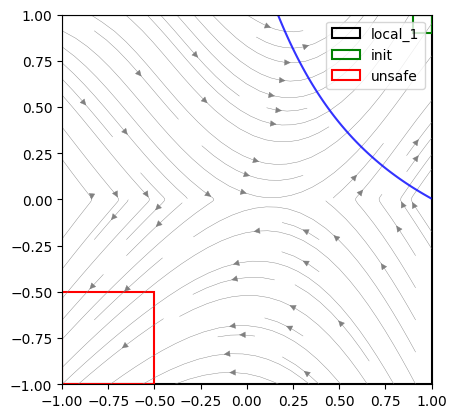

In [5]:

kvh = KVH(kvh_ex, kvh_ex.n_obs, l)
kvh.pos, vis = 1, False

t_learn, t_kvh, t_finetune = 0, 0, 0

for i in range(epoch):
    if adaptive_margin:
        config.margin = config.margin * 2
    print(f'Controller for epoch {i + 1}:{controller}')
    init, unsafe, domain, domain_dot = data.generate_data()
    t1 = time.time()
    print(f'---------------------------------------\nStart training--epoch {i + 1}\n'
            '---------------------------------------')
    learner.learn(opt, (init, unsafe, domain), domain_dot)

    t2 = time.time()
    t_learn += t2 - t1

    bc = learner.net.get_barrier()
    # print('bc:', bc)
    multiplier = learner.net.get_mul()
    # print('multiplier', multiplier)
    kvh.update_barrier(bc, multiplier, sp.sympify(controller))

    t3 = time.time()

    state = kvh.verify_all()

    t4 = time.time()
    t_kvh += t4 - t3
    if state:
        vis = True
        print_success()
        print(f'In the {i + 1} epoch, barrier certificate verification successful!')
        print(f'Barrier certificate:{bc}')
        print(f'Controller:{controller}')
        print(f'The time of learn:{t_learn}s')
        print(f'The time of verify:{t_kvh}s')
        print(f'The time of finetune:{t_finetune}s')
        if config.example.n_obs == 2:
            draw = Draw(config.example, bc, controller)
            draw.draw()
        break

    if vis:
        break

    print(f'Epoch {i + 1} failed verification barrier certificate:{bc}')
    print(f'---------------------------------------\nStart fine tuning--epoch {i + 1}\n'
            '---------------------------------------')

    finetuner = Finetuner(bc, config.example, controller, kvh, multiplier, config.device)

    t5 = time.time()

    finetuner.learn(*config_fine)

    t6 = time.time()
    t_finetune += t6 - t5
    controller, multiplier = finetuner.net.get_controller(config.example.n_obs)
    # print('controller:', controller)
    kvh.update_barrier(bc, multiplier, sp.sympify(controller))

    t3 = time.time()

    result = kvh.verify_all()

    t4 = time.time()
    t_kvh += t4 - t3
    if result:
        vis = True
        print_success()
        print(f'In the {i + 1} epoch, after the fine-tuning, barrier certificate verification successful!')
        print(f'Barrier certificate:{bc}')
        print(f'Controller:{controller}')
        print(f'The time of learn:{t_learn}s')
        print(f'The time of verify:{t_kvh}s')
        print(f'The time of finetune:{t_finetune}s')
        if config.example.n_obs == 2:
            draw = Draw(config.example, bc, controller)
            draw.draw()
        break
    else:
        data.update(controller)

if not vis:
    print('No barrier certificate found!')
